# 01. First QTT Function and Grid

## Learning goals

- see how a quantics grid turns one interval into `2^R` sample points
- build a QTT approximation of `cosh(x)` with the public Julia API
- inspect the bond dimensions of the resulting tensor train
- compare the QTT values with the exact function values
- repeat the workflow once more on a shifted interval with a second function

## Before you run this notebook

From a terminal in the repository root, run:

```bash
julia --project=. -e 'using Pkg; Pkg.instantiate(); Pkg.build("Tensor4all"); Pkg.precompile()'
```

Then open the notebook in VS Code or Jupyter and select the Julia kernel that matches the version you used for setup. This notebook was last tested with Julia 1.12.


In [103]:
using Tensor4all
using CairoMakie

const QG = Tensor4all.QuanticsGrids
const QTCI = Tensor4all.QuanticsTCI
const TN = Tensor4all.TensorNetworks
const STT = Tensor4all.SimpleTT

Tensor4all.SimpleTT

## Quantics grid in one dimension

A one-dimensional quantics grid is controlled by a bit depth `R`.
That means `2^R` sample points on the chosen interval.

Here we use `DiscretizedGrid{1}` with `includeendpoint=true` so the grid covers the closed interval `[0, 1]`.
The helper `grididx_to_origcoord` maps the grid point number back to the physical coordinate, and `grididx_to_quantics` shows the binary coordinates used by the QTT representation for that grid point.

In [104]:
R = 7
npoints = 1 << R
grid = QG.DiscretizedGrid{1}(R, 0.0, 1.0; includeendpoint=true)
xvals = [QG.grididx_to_origcoord(grid, i) for i in 1:npoints]

println("Grid ranges from $(first(xvals)) to $(last(xvals)) and has 2^R = $npoints points.")
println("Quantics representation of the first point is: $(QG.grididx_to_quantics(grid, 1))")
println("Quantics representation of the last point is: $(QG.grididx_to_quantics(grid, npoints))")

Grid ranges from 0.0 to 1.0 and has 2^R = 128 points.
Quantics representation of the first point is: [1, 1, 1, 1, 1, 1, 1]
Quantics representation of the last point is: [2, 2, 2, 2, 2, 2, 2]


## Main walkthrough: `cosh(x)`

The first function we study is `cosh(x)`. We will come back to why its QTT representation stays especially compact after we inspect the bond dimensions.
The QTT construction uses the public `QuanticsTCI` wrapper from `Tensor4all.jl`.

The object returned by `QuanticsTCI.quanticscrossinterpolate` stores the full interpolation result.
It contains the quantics grid, the cached function evaluations, and the TCI object itself.
The TCI object already contains the TT core data, together with interpolation-specific information such as errors and pivot sets.
Converting with `SimpleTT.TensorTrain(qtt.tci)` extracts the raw TT cores as plain Julia arrays.
We then convert these cores to `TensorNetworks.TensorTrain`, which adds explicit tensor indices and lets us inspect bond dimensions and evaluate the train in an index-aware way.

In [105]:
target_function(x) = cosh(x)

target_function (generic function with 1 method)

`quanticscrossinterpolate` asks for the value type explicitly. Here we use `Float64`, because the function values in this notebook are real floating-point numbers. We also keep `tolerance`, `maxbonddim`, and `maxiter` visible, because these are the main interpolation parameters to watch when building a QTT. In this notebook, `maxbonddim = 32` is just a generous ceiling, and the examples stay far below it.

In [106]:
value_type = Float64
tolerance = 1e-12
maxbonddim = 32
maxiter = 200

qtt, _, _ = QTCI.quanticscrossinterpolate(
    value_type,
    target_function,
    grid,
    ;
    tolerance=tolerance,
    maxbonddim=maxbonddim,
    maxiter=maxiter,
)

simple_tt = STT.TensorTrain(qtt.tci)
sites = [Tensor4all.Index(2; tags=["x", "bit=$i"]) for i in 1:length(simple_tt)]

indexed_tt = TN.TensorTrain(simple_tt, sites)
bond_dims = TN.linkdims(indexed_tt)

println("We interpolate values of type $value_type with tolerance = $tolerance, maxbonddim = $maxbonddim, and maxiter = $maxiter.")
println("The Tensor train consists of $(length(simple_tt)) core tensors, which matches the choice of R = $R.")
println("The bond dimensions of the tensor train are: $bond_dims")

We interpolate values of type Float64 with tolerance = 1.0e-12, maxbonddim = 32, and maxiter = 200.
The Tensor train consists of 7 core tensors, which matches the choice of R = 7.
The bond dimensions of the tensor train are: [2, 2, 2, 2, 2, 2]


So far we have built the QTT and inspected its bond dimensions. Before looking at one specific grid point, it is useful to check the approximation on the full grid. `cosh_exact` stores the exact function values at all sampled coordinates, `cosh_qtt` stores the corresponding values obtained from the QTT approximation, and `cosh_max_abs_error` measures the largest pointwise difference between the two lists.

In [107]:
cosh_exact = target_function.(xvals)
cosh_qtt = [real(qtt(i)) for i in 1:npoints]
cosh_max_abs_error = maximum(abs.(cosh_exact .- cosh_qtt))

println("Maximum absolute error between the QTT approximation and the exact function values is: $cosh_max_abs_error")

Maximum absolute error between the QTT approximation and the exact function values is: 4.440892098500626e-16


It is also possible to obtain values directly from the `TN.TensorTrain` object. For this, let's look at one sample grid point and compare to the true value at the corresponding physical coordinate.

In [108]:
sample_i = 17
sample_digits = QG.grididx_to_quantics(grid, sample_i)
sample_coordinate = QG.grididx_to_origcoord(grid, sample_i)

sample_qtt_value = qtt(sample_i)
sample_indexed_tt_value = real(TN.evaluate(indexed_tt, sites, sample_digits))
sample_exact_value = target_function(sample_coordinate)

println("sample_i = $sample_i")
println("sample_coordinate = $sample_coordinate")
println("sample_digits = $sample_digits")
println("sample_qtt_value = $sample_qtt_value")
println("sample_indexed_tt_value = $sample_indexed_tt_value")
println("sample_exact_value = $sample_exact_value")

sample_i = 17
sample_coordinate = 0.12598425196850394
sample_digits = [1, 1, 2, 1, 1, 1, 1]
sample_qtt_value = 1.0079465181517377
sample_indexed_tt_value = 1.0079465181517377
sample_exact_value = 1.0079465181517377


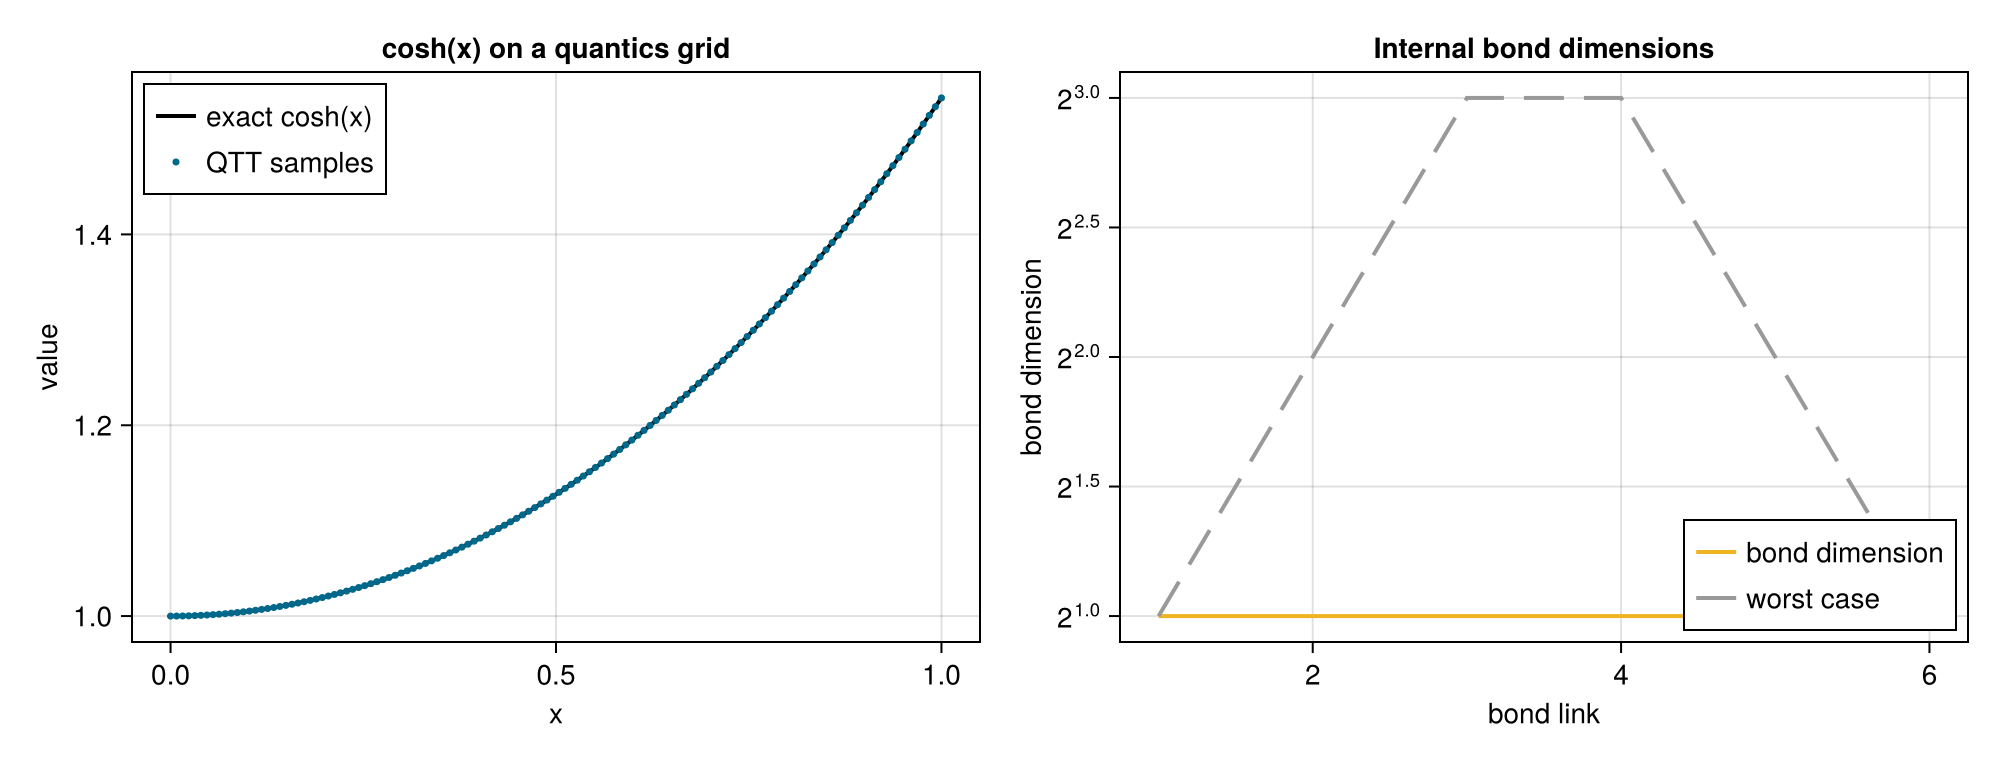

In [109]:
worst_case_bond_dims(num_bonds; base=2) = begin
    num_sites = num_bonds + 1
    half = num_sites ÷ 2
    up = [base^x for x in 1:half]
    down = reverse(up)
    if length(up) + length(down) >= num_sites
        down = down[2:end]
    end
    [up..., down...]
end

fig = Figure(size=(1000, 380))

ax1 = Axis(
    fig[1, 1],
    xlabel="x",
    ylabel="value",
    title="cosh(x) on a quantics grid",
)
lines!(ax1, xvals, cosh_exact; color=:black, linewidth=2, label="exact cosh(x)")
scatter!(ax1, xvals, cosh_qtt; color=:deepskyblue4, markersize=5, label="QTT samples")
axislegend(ax1; position=:lt)

ax2 = Axis(
    fig[1, 2],
    xlabel="bond link",
    ylabel="bond dimension",
    title="Internal bond dimensions",
    yscale=log2,
)
bond_index = 1:length(bond_dims)
lines!(ax2, bond_index, bond_dims; color=:goldenrod2, linewidth=2, label="bond dimension")
lines!(ax2, bond_index, worst_case_bond_dims(length(bond_dims)); color=:gray60, linewidth=2, linestyle=Linestyle([0, 10, 15]), label="worst case")
axislegend(ax2; position=:rb)

fig

#### Why `cosh(x)` stays compact

The function `cosh(x)` is a good first example because

    cosh(x) = (exp(x) + exp(-x)) / 2.

On a quantics grid, the binary digits of the grid index contribute additively to the coordinate `x`. Exponentials turn sums into products, so `exp(x)` and `exp(-x)` can be represented very compactly across the bit sites. Since `cosh(x)` is a sum of two such exponentials, seeing bond dimensions close to `2` is not accidental: it reflects the structure of the function.


## Second experiment: a shifted interval

The same workflow also works on a shifted interval.
Now the grid covers `[-1, 2]`, while the target function stays simple.
This keeps the focus on the role of the physical interval.
Try changing `experiment_function`, the interval bounds, or `R`, then rerun the next two cells and compare the new error and bond dimensions.


In [110]:
experiment_function(x) = x^2

experiment_function (generic function with 1 method)

We reuse the same interpolation settings here, so the main change in this second example is the physical interval.

In [111]:
experiment_grid = QG.DiscretizedGrid{1}(R, -1.0, 2.0; includeendpoint=true)
experiment_xvals = [QG.grididx_to_origcoord(experiment_grid, i) for i in 1:npoints]

experiment_qtt, _, _ = QTCI.quanticscrossinterpolate(
    value_type,
    experiment_function,
    experiment_grid,
    ;
    tolerance=tolerance,
    maxbonddim=maxbonddim,
    maxiter=maxiter,
)

experiment_simple_tt = STT.TensorTrain(experiment_qtt.tci)
experiment_sites = [Tensor4all.Index(2; tags=["u", "bit=$i"]) for i in 1:length(experiment_simple_tt)]
experiment_indexed_tt = TN.TensorTrain(experiment_simple_tt, experiment_sites)
experiment_bond_dims = TN.linkdims(experiment_indexed_tt)

experiment_exact = experiment_function.(experiment_xvals)
experiment_values = [real(experiment_qtt(i)) for i in 1:npoints]
experiment_max_abs_error = maximum(abs.(experiment_exact .- experiment_values))

println("We interpolate values of type $value_type with tolerance = $tolerance, maxbonddim = $maxbonddim, and maxiter = $maxiter.")
println("The shifted grid ranges from $(first(experiment_xvals)) to $(last(experiment_xvals)).")
println("The bond dimensions of the tensor train are: $experiment_bond_dims")
println("Maximum absolute error between the QTT approximation and the exact function values is: $experiment_max_abs_error")

We interpolate values of type Float64 with tolerance = 1.0e-12, maxbonddim = 32, and maxiter = 200.
The shifted grid ranges from -1.0 to 2.0.
The bond dimensions of the tensor train are: [2, 3, 3, 3, 3, 2]
Maximum absolute error between the QTT approximation and the exact function values is: 1.7763568394002505e-15


This is the same comparison as before, but now on the shifted interval. `experiment_exact` stores the exact values of the experiment function on `[-1, 2]`, `experiment_values` stores the corresponding values obtained from the QTT approximation, and `experiment_max_abs_error` measures the largest pointwise difference between the two lists.


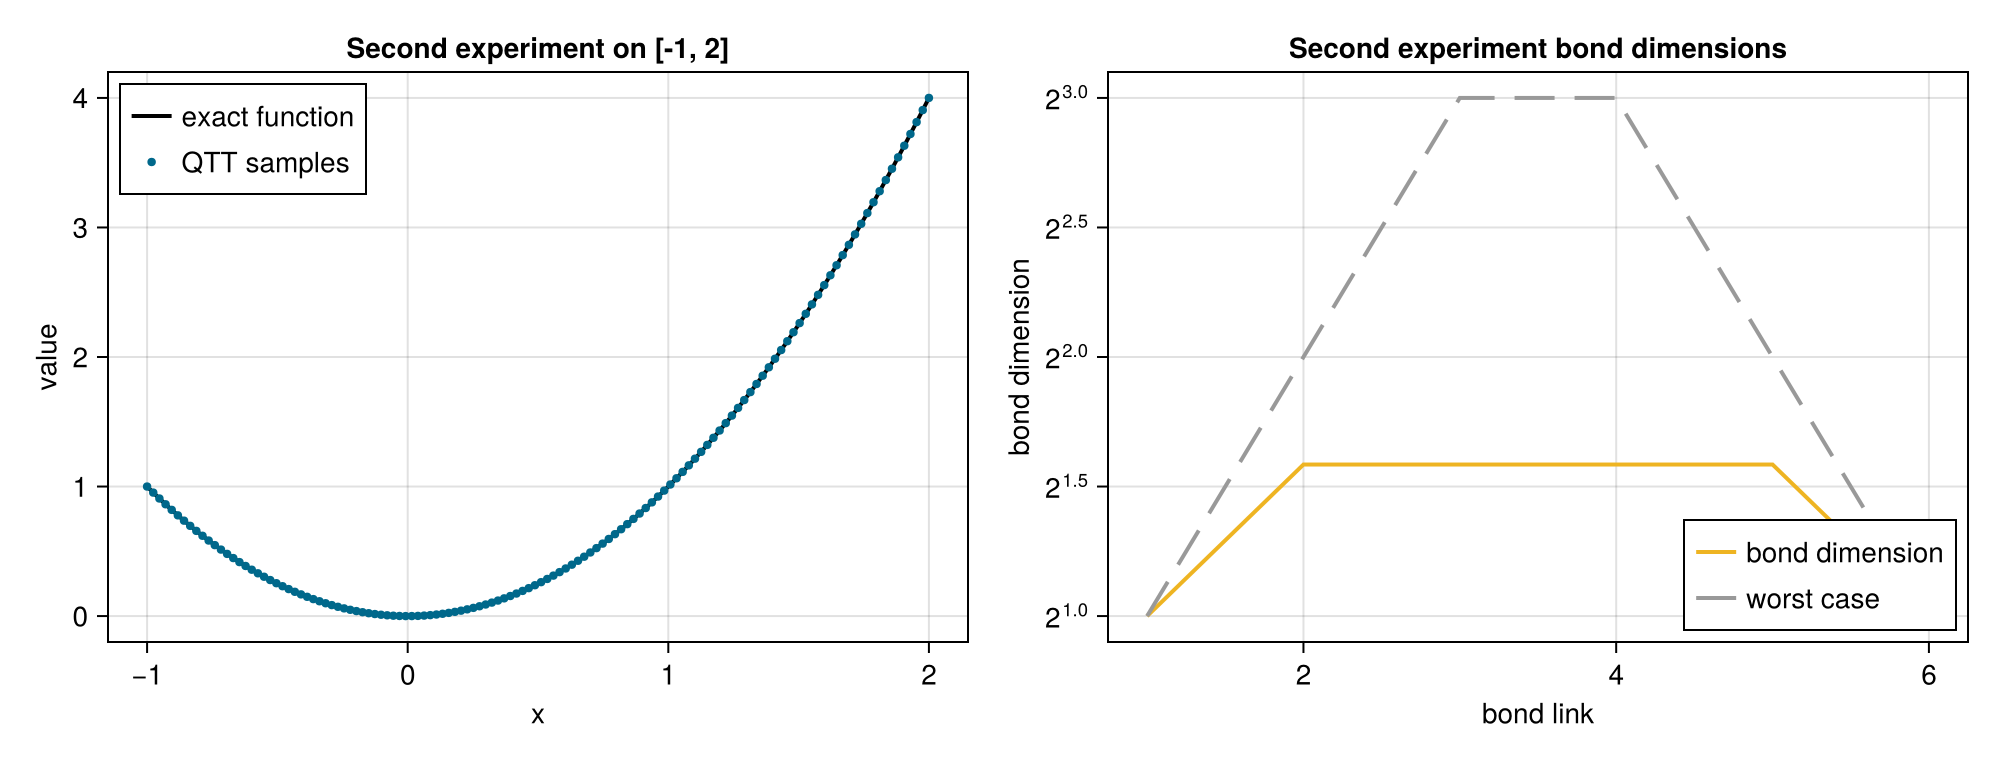

In [112]:
fig2 = Figure(size=(1000, 380))

ax3 = Axis(
    fig2[1, 1],
    xlabel="x",
    ylabel="value",
    title="Second experiment on [-1, 2]",
)
lines!(ax3, experiment_xvals, experiment_exact; color=:black, linewidth=2, label="exact function")
scatter!(ax3, experiment_xvals, experiment_values; color=:deepskyblue4, markersize=6, label="QTT samples")
axislegend(ax3; position=:lt)

ax4 = Axis(
    fig2[1, 2],
    xlabel="bond link",
    ylabel="bond dimension",
    title="Second experiment bond dimensions",
    yscale=log2,
)
experiment_bond_index = 1:length(experiment_bond_dims)
lines!(ax4, experiment_bond_index, experiment_bond_dims; color=:goldenrod2, linewidth=2, label="bond dimension")
lines!(ax4, experiment_bond_index, worst_case_bond_dims(length(experiment_bond_dims)); color=:gray60, linewidth=2, linestyle=Linestyle([0, 10, 15]), label="worst case")
axislegend(ax4; position=:rb)

fig2

## What to notice

- `R` controls the bit depth and therefore the number of grid points.
- `QuanticsTCI.quanticscrossinterpolate` builds the QTT from a function callback on a quantics grid.
- `SimpleTT.TensorTrain(qtt.tci)` exposes the raw tensor cores.
- `TensorNetworks.TensorTrain(simple_tt, sites)` turns the raw TT into a tensor-network representation with explicit indices.
- `TensorNetworks.evaluate` reads a value back from that representation.
- `TensorNetworks.linkdims` shows the internal bond-dimension profile.


## API recap

- `Tensor4all.QuanticsGrids.DiscretizedGrid{1}`
- `Tensor4all.QuanticsGrids.grididx_to_origcoord`
- `Tensor4all.QuanticsGrids.grididx_to_quantics`
- `Tensor4all.QuanticsTCI.quanticscrossinterpolate`
- `Tensor4all.SimpleTT.TensorTrain`
- `Tensor4all.TensorNetworks.TensorTrain`
- `Tensor4all.TensorNetworks.evaluate`
- `Tensor4all.TensorNetworks.linkdims`

Notebook 02 will pick up the accuracy and bond-dimension story in more detail.